In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## Sensitization screen

In [5]:
data = pd.read_excel("../data/2020_05_18_PPH_ludwig_data.xlsx")
data["Controls"] = [str(x) for x in data["Controls"]]
data["Compound Names"] = [str(x) for x in data["Compound Names"]]

In [6]:
data.head()

,Plate,Well,Library,Library Well Type,Reagent Vendor,Vendor Reagent ID,Controls,Compound Names,Concentration,Log[M],...,Count of Live Cells Size Filter.3,Count of DAPI negative singlets.3,Live Cells Size Filter as % of All Cells.3,DAPI negative singlets as % of All Cells.3,CD11b neg GFP neg.3,CD11b pos GFP neg.3,CD11b pos GFP pos.3,Cd11b pos total.3,GeoMean GFP-H (BL1-H) of DAPI negative singlets.3,GeoMean APC-H (RL1-H) of DAPI negative singlets.3
0,3865,A01,Ludwig Metabolic Library 2,empty,NaN,NaN,DMSO,nan,NaN,NaN,...,13723,11403,64.633572,53.706669,31.263703,22.301149,41.682014,63.983162,26409.443512,64461.864390
1,3865,A02,Ludwig Metabolic Library 2,empty,NaN,NaN,DMSO,nan,NaN,NaN,...,15543,12636,65.098844,52.923438,28.157645,24.192783,42.909148,67.101931,27143.980393,71279.548894
2,3865,A03,Ludwig Metabolic Library 2,empty,NaN,NaN,DMSO,nan,NaN,NaN,...,13524,11442,64.667910,54.712380,30.746373,22.880615,41.845831,64.726446,25883.998497,66847.684040
3,3865,A04,Ludwig Metabolic Library 2,empty,NaN,NaN,DMSO,nan,NaN,NaN,...,14819,11966,65.141325,52.600114,25.931807,25.697810,44.300518,69.998329,28603.850921,76254.701990
4,3865,A05,Ludwig Metabolic Library 2,empty,NaN,NaN,DMSO,nan,NaN,NaN,...,13570,11388,65.419660,54.900448,29.548648,22.620302,42.860906,65.481208,27555.418778,69474.636229


In [9]:
data.columns

Index(['Plate', 'Well', 'Library', 'Library Well Type', 'Reagent Vendor',
       'Vendor Reagent ID', 'Controls', 'Compound Names', 'Concentration',
       'Log[M]', 'Well.1', 'Well Number 384', '384 WELL', '96 WELL',
       'QUADRANT', 'DATA PLATE REP A', 'Well ID', 'Well Type',
       'Count of All Cells', 'Count of Live Cells Size Filter',
       'Count of DAPI negative singlets',
       'Live Cells Size Filter as % of All Cells',
       'DAPI negative singlets as % of All Cells', 'CD11b neg GFP neg',
       'CD11b pos GFP neg', 'CD11b pos GFP pos', 'Cd11b pos total',
       'GeoMean GFP-H (BL1-H) of DAPI negative singlets',
       'GeoMean APC-H (RL1-H) of DAPI negative singlets', 'DATA PLATE REP B',
       'Well ID.1', 'Well Type.1', 'Count of All Cells.1',
       'Count of Live Cells Size Filter.1',
       'Count of DAPI negative singlets.1',
       'Live Cells Size Filter as % of All Cells.1',
       'DAPI negative singlets as % of All Cells.1', 'CD11b neg GFP neg.1',
       'CD

In [10]:
plates = []
for plate in np.unique(data["Plate"]):
    plates.append(data[data["Plate"] == plate])

In [11]:
# the first 5 plates have a mean of 35-52 with just BRQ added; the last 5 plates have a mean between 73 and 82
[np.mean(plates[i][plates[i]["Controls"] == "DMSO"]["CD11b pos GFP pos.2"]) for i in range(len(plates))]

[45.06994830607245,
 52.0829533614548,
 35.444057214633844,
 51.22482695145872,
 45.19532805075164,
 79.58768519966276,
 82.80996612153919,
 82.61382195645807,
 73.12623667082055,
 76.85178952405211]

<ipython-input-22-03fc2d9a8314>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1["rep"] = "rep1"
<ipython-input-22-03fc2d9a8314>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2["rep"] = "rep2"


<AxesSubplot:xlabel='log_M', ylabel='viability'>

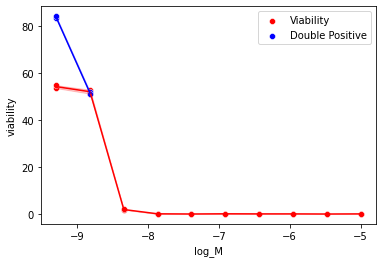

In [22]:
# test out plot making
i = 7
plate = plates[i]
drug = "Actinomycin D"
data = plate[plate["Compound Names"] == drug][["Log[M]", "DAPI negative singlets as % of All Cells.2",
                                                        "CD11b pos GFP pos.2", "DAPI negative singlets as % of All Cells.3",
                                                        "CD11b pos GFP pos.3"]]
data = data.sort_values(by="Log[M]", ascending=True)
data1 = data.iloc[:,:3]
data2 = data.iloc[:,[0,3,4]]
data1["rep"] = "rep1"
data2["rep"] = "rep2"
data1.columns = data2.columns = ["log_M", "viability", "double_pos", "rep"]
to_plot = pd.concat([data1, data2], axis=0)
to_plot[to_plot["viability"] > 2]
sns.scatterplot(x="log_M", y="viability", color="red", data=to_plot, label="Viability")
sns.scatterplot(x="log_M", y="double_pos", color="blue", data=to_plot[to_plot["viability"] > 2], label="Double Positive")
sns.lineplot(x="log_M", y="viability", color="red", data=to_plot)
sns.lineplot(x="log_M", y="double_pos", color="blue", data=to_plot[to_plot["viability"] > 2])

# 
# plt.legend()
# plt.ylabel("Percent cells")

In [208]:
# make figs
plate = plates[i]
for i in range(len(plates)):
    plate = plates[i]
    print(i)
    
    brq_diff_mean = np.mean(plates[i][plates[i]["Controls"] == "DMSO"]["CD11b pos GFP pos.2"])
    brq_viab_mean = np.mean(plates[i][plates[i]["Controls"] == "DMSO"]["DAPI negative singlets as % of All Cells.2"])

    for drug in np.unique(plate["Compound Names"]):
        if drug == "nan": continue
        data = plate[plate["Compound Names"] == drug][["Log[M]", "DAPI negative singlets as % of All Cells.2",
                                                                "CD11b pos GFP pos.2", "DAPI negative singlets as % of All Cells.3",
                                                                "CD11b pos GFP pos.3"]]
        data = data.sort_values(by="Log[M]", ascending=True)
        data1 = data.iloc[:,:3]
        data2 = data.iloc[:,[0,3,4]]
        data1["rep"] = "rep1"
        data2["rep"] = "rep2"
        data1.columns = data2.columns = ["log_M", "viability", "double_pos", "rep"]
        to_plot = pd.concat([data1, data2], axis=0)
        plt.figure(figsize=[4.5,3])
        
        # find the highest dose that doesn't lead to tox 
        max_dose = data.iloc[0,0]
        for j in range(data.shape[0]):
            viab = np.mean(data.iloc[j,[1,3]])
            if viab <= 2: 
                max_dose = data.iloc[j-1,0]
                break
            max_dose = data.iloc[j,0]
        
        sns.scatterplot(x="log_M", y="viability", color="black", data=to_plot, s=10)
        sns.lineplot(x="log_M", y="viability", color="darkred", data=to_plot, label="Viability", ci=None)

        if j > 0:
            sns.scatterplot(x="log_M", y="double_pos", color="black", data=to_plot[to_plot["log_M"] <= max_dose], s=10)
            sns.lineplot(x="log_M", y="double_pos", color="darkblue", \
                         data=to_plot[to_plot["log_M"] <= max_dose], ci=None, label="Double Positive")
        plt.legend()
        plt.ylabel("Percent cells")
 
        plt.axhline(brq_viab_mean, linestyle='--', color="pink")
        plt.axhline(brq_diff_mean, linestyle='--', color="lightblue")
        plt.ylim([-5,105])
        plt.title(drug)
        plt.tight_layout()
        plt.savefig("../output/bd_c46_graphs/" + drug + ".pdf")
        plt.clf()

0


/usr/local/Caskroom/miniconda/base/lib/python3.7/site-packages/ipykernel_launcher.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/usr/local/Caskroom/miniconda/base/lib/python3.7/site-packages/ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


1
2
3
4
5
6
7
8
9


<Figure size 324x216 with 0 Axes>

<Figure size 324x216 with 0 Axes>

...

<Figure size 324x216 with 0 Axes>

<Figure size 324x216 with 0 Axes>

<Figure size 324x216 with 0 Axes>

<Figure size 324x216 with 0 Axes>

<Figure size 324x216 with 0 Axes>

In [12]:
plate = plates[1]
plate[plate["Compound Names"] == "Brequinar sodium salt hydrate"][["Log[M]", "DAPI negative singlets as % of All Cells.2",
                                                                "CD11b pos GFP pos.2", "DAPI negative singlets as % of All Cells.3",
                                                                "CD11b pos GFP pos.3"]]

,Log[M],DAPI negative singlets as % of All Cells.2,CD11b pos GFP pos.2,DAPI negative singlets as % of All Cells.3,CD11b pos GFP pos.3
516,-5.000000,3.503185,72.027972,17.198723,60.672854
517,-5.477121,5.664970,71.484375,5.499188,80.442800
518,-5.954243,12.805430,83.392226,15.060423,74.824473
519,-6.431364,24.682893,74.814815,23.209140,82.796690
520,-6.908485,40.920771,74.969475,40.296763,75.719705
521,-7.385606,49.783186,64.456308,51.026690,62.807020
522,-7.862728,53.062299,55.964669,54.383057,57.128344
523,-8.339849,54.145688,53.031952,56.323830,54.405350
524,-8.816970,54.546677,52.486642,55.866813,52.667737
525,-9.294091,53.664188,55.055728,54.711460,53.664960


In [13]:
# get sensitivity data 
#plate = plates[i]
drugs = []
doses = []
diffs = []
viabs = []
for i in range(len(plates)):
    plate = plates[i]
    print(i)
    
    brq_diff_mean = np.mean(plates[i][plates[i]["Controls"] == "DMSO"]["CD11b pos GFP pos.2"])
    brq_viab_mean = np.mean(plates[i][plates[i]["Controls"] == "DMSO"]["DAPI negative singlets as % of All Cells.2"])

    for drug in np.unique(plate["Compound Names"]):
        if drug == "nan": continue
        data = plate[plate["Compound Names"] == drug][["Log[M]", "DAPI negative singlets as % of All Cells.2",
                                                                "CD11b pos GFP pos.2", "DAPI negative singlets as % of All Cells.3",
                                                                "CD11b pos GFP pos.3"]]
        data = data.sort_values(by="Log[M]", ascending=True)
        
        # find the highest dose that doesn't lead to tox 
        for j in range(data.shape[0]):
            viab = np.mean(data.iloc[j,[1,3]])
            if viab <= 2:
                j = j-1
                break
        
        
        print(drug, j)  
        # keep values for the last j 
        if j == -1: continue  # every dose is too toxic
        diff = np.mean(data.iloc[j,[2,4]])
        
#         # viab and diff at the highest dose with >2% viability
#         viab = np.mean(data.iloc[j,[1,3]])
#         diff = np.mean(data.iloc[j,[2,4]])
#         print(viab, diff)
        
        # go backwards and find the least toxic dose where diff is changed less than 10 percent 
        if diff < np.mean(data.iloc[0,[2,4]]):  # something that reduces diff
            temp_d = np.min(np.mean(data.iloc[0:j+1,[2,4]], axis=1))
            temp_j = np.argmin(np.mean(data.iloc[0:j+1,[2,4]], axis=1))
            print(temp_d, temp_j)
            temp_v = np.mean(data.iloc[temp_j,[1,3]])
            for k in range(-temp_j, 0):  # going backwards
                elem = -k   # flipping the number
                elem_viab = np.mean(data.iloc[elem, [1,3]])
                elem_diff = np.mean(data.iloc[elem, [2,4]])
                if elem_diff - temp_d < 10: 
                    temp_v = elem_viab
                    temp_d = elem_diff
                else: break 
        else:  # something that increases diff
            temp_d = np.max(np.mean(data.iloc[0:j+1,[2,4]], axis=1))
            temp_j = np.argmax(np.mean(data.iloc[0:j+1,[2,4]], axis=1))
            print(temp_d, temp_j)
            temp_v = np.mean(data.iloc[temp_j,[1,3]])
            for k in range(-temp_j, 0):  # going backwards
                elem = -k   # flipping the number
                elem_viab = np.mean(data.iloc[elem, [1,3]])
                elem_diff = np.mean(data.iloc[elem, [2,4]])
                if temp_d - elem_diff < 10: 
                    temp_v = elem_viab
                    temp_d = elem_diff
                else: break
                
        viab = temp_v
        diff = temp_d            
        print(viab, diff)
        drugs.append(drug)
        diffs.append((diff - brq_diff_mean)/(brq_diff_mean) * 100)
        viabs.append((viab - brq_viab_mean)/(brq_viab_mean) * 100)

0
(R)-(+)-Etomoxir sodium salt 9
41.380764491350305 9
56.5829120712214 42.11762477803725
1-Deoxynojirimycin 9
41.59280784520425 9
56.15386172349724 43.3467733195289
17-AAG (Tanespimycin) 9
57.872873916865146 8
54.82962566520215 43.5161070286155
2-Deoxy-D-glucose 9
24.21263217196565 9
58.607713154263195 24.21263217196565
2-Methoxyestradiol 7
36.120433843301 7
53.357218305687496 44.34688403753065
3,3?-Methylene-bis(4-hydroxy-coumarin) 9
46.487919454422794 8
56.61150904720215 42.8244346235146
3-Nitropropionic acid 9
37.816445840250154 9
55.293101887932394 43.59846401399205
3PO 9
42.54244261424135 9
56.33345677201995 44.060757730991355
4mu8C 9
48.0400147295055 7
54.99128084751855 43.9822900380152
5-Fluorouracil 3
65.90619202226344 3
51.667250988071004 48.74661779092655
6-Aminonicotinamide 9
29.645458757628 9
57.36300914828145 29.645458757628
6-Azauridine 9
78.38378363573725 8
35.400267442258794 77.29883956593395
6-Mercaptopurine 9
69.9659055597894 9
24.9295764775892 69.9659055597894
6-Thio

In [14]:
sens_data = pd.DataFrame([drugs, diffs, viabs]).transpose()
sens_data.columns = ["drug", "diff", "viab"]
sens_data = sens_data.sort_values(by="diff")
sens_data

,drug,diff,viab
68,Diphenyleneiodonium chloride,-99.694613,8.700989
160,Spautin 1,-99.302839,130.751811
84,Fenretinide,-97.968862,-43.169261
146,Pyrvinium pamoate salt hydrate,-97.701932,133.643321
33,Artesunate,-97.076666,-3.6398
...,...,...,...
11,6-Azauridine,71.508605,-32.895032
104,Lapachol,75.088084,-42.028487
69,Dipyridamole,83.635261,-3.248261
61,Cyclopentenyl cytosine,130.366797,-56.880254


In [15]:
sens_data[sens_data["drug"] == "6-Azauridine"]

,drug,diff,viab
11,6-Azauridine,71.508605,-32.895032


In [67]:
sens_data.to_csv("../output/210511_bd_c46_sens_data.csv")

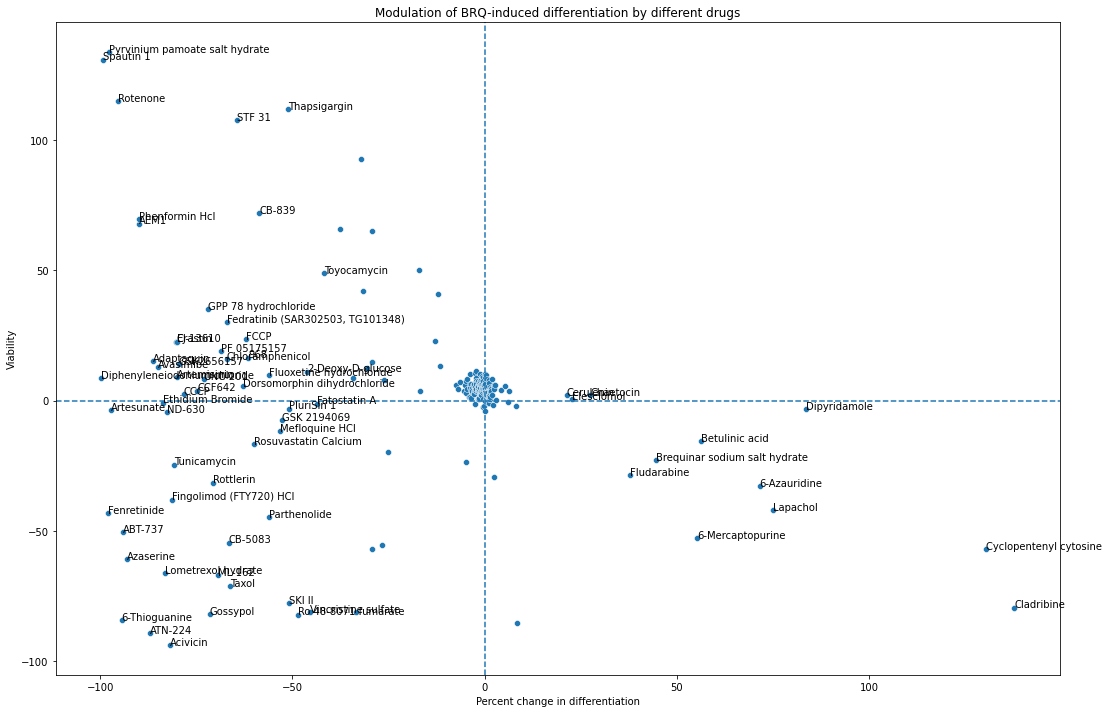

In [68]:
plt.figure(figsize=[18,12])
sns.scatterplot(x="diff", y="viab", data=sens_data)
for i in range(sens_data.shape[0]):
    row = sens_data.iloc[i,:]
    if row["diff"] < -40 or row["diff"] > 20:
        plt.annotate(row["drug"], (row["diff"], row["viab"]))
plt.xlabel("Percent change in differentiation")
plt.ylabel("Percent change in Viability")
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')

plt.title("Modulation of BRQ-induced differentiation by different drugs")
plt.savefig("../output/210511_bd_c46_sens_data.pdf")

In [24]:
drug_annot = pd.read_excel("~/Dropbox (MIT)/Shared Nucleotide Differentiation/BRQ sensitizing screen data/2020_08_08_output_final from Raphael_v1.xlsx")

In [25]:
drug_annot = drug_annot[["drug", "Pathway"]]
drug_annot.index = drug_annot["drug"]
drug_annot = drug_annot.reindex(sens_data["drug"])
drug_annot["diff"] = np.array(sens_data["diff"])
drug_annot = drug_annot.replace(to_replace='Nucleotide_Metabolism', 
                   value='NucleotideMetabolism')
drug_annot


,drug,Pathway,diff
drug,,,
Diphenyleneiodonium chloride,Diphenyleneiodonium chloride,Redoxhomeostasis,-99.694613
Spautin 1,Spautin 1,Autophagy_ERstress,-99.302839
Fenretinide,Fenretinide,Hormone,-97.968862
Pyrvinium pamoate salt hydrate,Pyrvinium pamoate salt hydrate,Hormone,-97.701932
Artesunate,Artesunate,Redoxhomeostasis,-97.076666
...,...,...,...
6-Azauridine,6-Azauridine,NucleotideMetabolism,71.508605
Lapachol,Lapachol,NucleotideMetabolism,75.088084
Dipyridamole,Dipyridamole,Hormone,83.635261


In [28]:
drug_annot.to_csv("../output/210511_bd_c46_bypathway.csv")


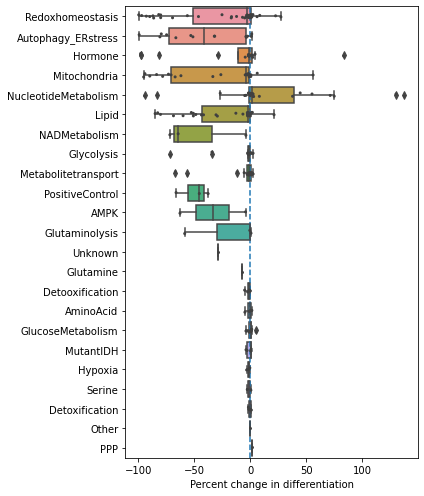

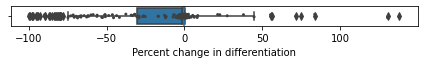

In [26]:
plt.figure(figsize=[6,7])
sns.boxplot(x = [x for x in np.array(sens_data["diff"])], y = [x for x in drug_annot["Pathway"]])
sns.stripplot(x = [x for x in np.array(sens_data["diff"])], y = [x for x in drug_annot["Pathway"]], color=".25", s=3)
plt.axvline(0, linestyle='--')
plt.xlabel("Percent change in differentiation")
plt.tight_layout()
plt.savefig("../output/210511_bd_c46_sens_by_category_boxplot.pdf")

plt.figure(figsize=[6,1])
sns.boxplot(x = [x for x in np.array(sens_data["diff"])])
sns.stripplot(x = [x for x in np.array(sens_data["diff"])], color=".25", s=3)
plt.axvline(0, linestyle='--')
plt.xlabel("Percent change in differentiation")
plt.tight_layout()
plt.savefig("../output/210511_bd_c46_sens_boxplot.pdf")

<AxesSubplot:xlabel='count'>

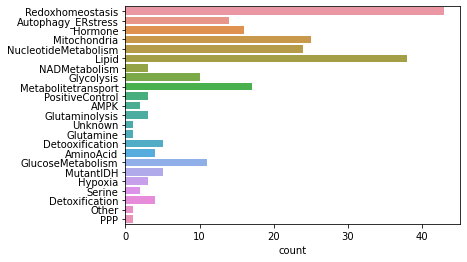

In [27]:
sns.countplot(y=[x for x in drug_annot["Pathway"]])